<a href="https://colab.research.google.com/github/lguhstavol/Projeto-A3-Inteligencia-artificial/blob/main/A3_inteligencia_artificial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Justificativa do Projeto**
O Spotify está presente no cotidiano da maioria dos brasileiros. Realizar uma previsão de gênero musical com base em atributos sonoros é um desafio interessante que nos permite entender como a tecnologia auxilia na curadoria musical que consumimos diariamente.

In [ ]:
# =====================================================================
# PROJETO A3 - SISTEMAS DE INFORMAÇÃO
# Comitê de Classificadores para Predição de Gênero Musical
# =====================================================================

# =====================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Modelos Individuais
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Comitê
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Balanceamento
from imblearn.over_sampling import SMOTE
from collections import Counter

print("✅ Todas as bibliotecas importadas com sucesso!")
print("📊 Projeto A3 - Comitê de Classificadores para Previsão de Gênero Musical\n")

✅ Todas as bibliotecas importadas com sucesso!
📊 Projeto A3 - Comitê de Classificadores para Previsão de Gênero Musical



### **1. Importação de Bibliotecas**
Nesta célula, carregamos as ferramentas necessárias: `pandas` para dados, `sklearn` para a inteligência artificial (incluindo os modelos KNN, Decision Tree e Naive Bayes) e bibliotecas de visualização para gerar os gráficos de desempenho.

In [ ]:
# =====================================================================
# 2. CARREGAMENTO DA BASE DE DADOS
# =====================================================================
# Tente carregar do ambiente local primeiro
try:
    df = pd.read_csv('spotify_alltime_top100_songs.csv')
    print("✅ Arquivo carregado do ambiente local!")
except FileNotFoundError:
    print("📁 Faça o upload do arquivo 'spotify_alltime_top100_songs.csv':")
    uploaded = files.upload()
    df = pd.read_csv('spotify_alltime_top100_songs.csv')

print(f"\n📊 Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"📋 Colunas disponíveis: {list(df.columns)}")

📁 Faça o upload do arquivo 'spotify_alltime_top100_songs.csv':


Saving spotify_alltime_top100_songs.csv to spotify_alltime_top100_songs.csv

📊 Dimensões do dataset: 100 linhas × 14 colunas
📋 Colunas disponíveis: ['alltime_rank', 'song_title', 'artist', 'total_streams_billions', 'primary_genre', 'bpm', 'release_year', 'artist_country', 'explicit', 'danceability', 'energy', 'valence', 'acousticness', 'dataset_part']


### **2. Carregamento da Base de Dados**
Aqui fazemos o upload ou a leitura do arquivo CSV contendo o Top 100 do Spotify. O código verifica se o arquivo já existe no ambiente para facilitar a execução repetida.


ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)

📌 Tipos de dados:
object     5
float64    5
int64      3
bool       1
Name: count, dtype: int64

📌 Dados ausentes por coluna:
Empty DataFrame
Columns: [Ausentes, Percentual]
Index: []

📌 Estatísticas descritivas das features numéricas:
       alltime_rank  total_streams_billions         bpm  release_year  \
count    100.000000              100.000000  100.000000    100.000000   
mean      50.500000                2.524600  115.780000   2016.800000   
std       29.011492                0.851432   30.540776      7.063922   
min        1.000000                1.400000   62.000000   1985.000000   
25%       25.750000                1.735000   95.000000   2016.000000   
50%       50.500000                2.435000  107.000000   2018.500000   
75%       75.250000                3.167500  139.000000   2021.000000   
max      100.000000                5.260000  191.000000   2024.000000   

       danceability      energy     valence  acousticness  
count  

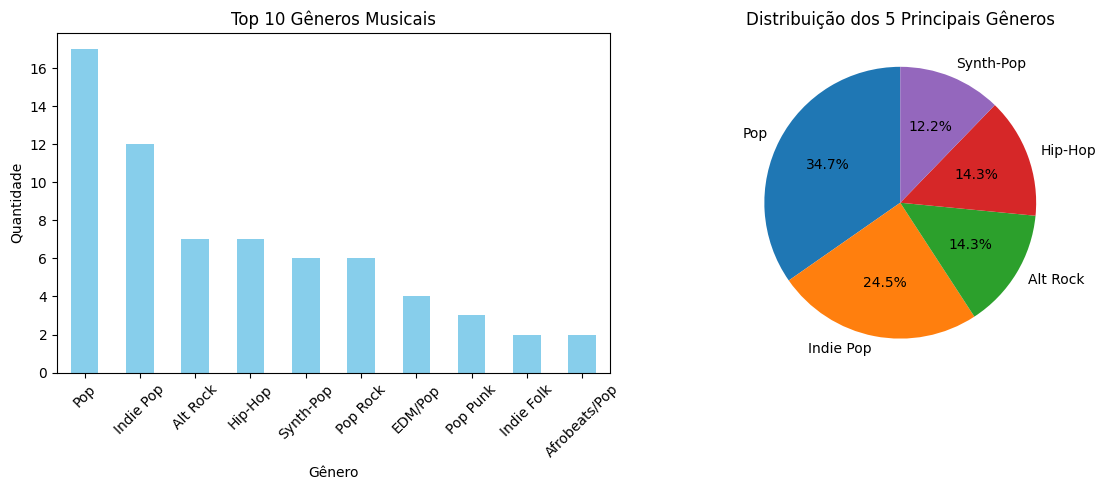

In [ ]:
# =====================================================================
# 3. ANÁLISE EXPLORATÓRIA (EDA) - REQUISITO 3.3
# =====================================================================
print("\n" + "="*70)
print("ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)")
print("="*70)

# 3.1 Informações gerais
print("\n📌 Tipos de dados:")
print(df.dtypes.value_counts())

# 3.2 Verificação de dados ausentes
print("\n📌 Dados ausentes por coluna:")
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual': missing_pct})
print(missing_df[missing_df['Ausentes'] > 0])

# 3.3 Estatísticas descritivas
print("\n📌 Estatísticas descritivas das features numéricas:")
print(df.describe())

# 3.4 Distribuição do gênero musical (target)
print("\n📌 Distribuição original dos gêneros:")
if 'primary_genre' in df.columns:
    genre_counts = df['primary_genre'].value_counts()
    print(genre_counts)

    # Visualização
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    genre_counts.head(10).plot(kind='bar', color='skyblue')
    plt.title('Top 10 Gêneros Musicais', fontsize=12)
    plt.xlabel('Gênero')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    plt.pie(genre_counts.head(5).values, labels=genre_counts.head(5).index,
            autopct='%1.1f%%', startangle=90)
    plt.title('Distribuição dos 5 Principais Gêneros')
    plt.tight_layout()
    plt.show()

### **3. Mapeamento e Pré-processamento**
Nesta etapa crucial:
1. Definimos a **Variável Alvo**: Gênero Musical (`primary_genre`).
2. Definimos as **Variáveis Independentes (Features)**: BPM, Dançabilidade, Energia e Valência.
3. Realizamos a limpeza de dados e a padronização de escalas, garantindo que o modelo trate todas as características com a mesma importância.

In [ ]:
# =====================================================================
# 4. DEFINIÇÃO DO PROBLEMA - REQUISITO 3.2
# =====================================================================
print("\n" + "="*70)
print("DEFINIÇÃO DO PROBLEMA")
print("="*70)
print("""
🎯 VARIÁVEL TARGET (ALVO):
   → primary_genre (Gênero musical principal da música)
   → O que se deseja prever: Classificar uma música em seu gênero musical
     com base em suas características sonoras.

📊 VARIÁVEIS INDEPENDENTES (FEATURES):
   → bpm (Batidas por minuto) - ritmo da música
   → danceability (Dançabilidade) - quão adequada é para dançar
   → energy (Energia) - intensidade percebida da música
   → valence (Valência) - positividade/música feliz vs triste
   → acousticness (Acusticidade) - presença de instrumentos acústicos
   → loudness (Volume) - intensidade sonora em decibéis
   → speechiness (Fala) - presença de palavras faladas
   → instrumentalness (Instrumentalidade) - ausência de vocais

🔬 PROBLEMA DE NEGÓCIO:
   O Spotify e outras plataformas de streaming precisam recomendar músicas
   baseadas no gosto do usuário. Um sistema de classificação de gênero
   automatizado permite:

   1. Criar playlists personalizadas
   2. Melhorar sistemas de recomendação
   3. Analisar tendências musicais
   4. Auxiliar artistas a posicionarem seu trabalho

🎯 OBJETIVO DO PROJETO:
   Construir um comitê de classificadores que supere o desempenho de
   modelos individuais na predição do gênero musical.
""")


DEFINIÇÃO DO PROBLEMA

🎯 VARIÁVEL TARGET (ALVO):
   → primary_genre (Gênero musical principal da música)
   → O que se deseja prever: Classificar uma música em seu gênero musical
     com base em suas características sonoras.

📊 VARIÁVEIS INDEPENDENTES (FEATURES):
   → bpm (Batidas por minuto) - ritmo da música
   → danceability (Dançabilidade) - quão adequada é para dançar
   → energy (Energia) - intensidade percebida da música
   → valence (Valência) - positividade/música feliz vs triste
   → acousticness (Acusticidade) - presença de instrumentos acústicos
   → loudness (Volume) - intensidade sonora em decibéis
   → speechiness (Fala) - presença de palavras faladas
   → instrumentalness (Instrumentalidade) - ausência de vocais

🔬 PROBLEMA DE NEGÓCIO:
   O Spotify e outras plataformas de streaming precisam recomendar músicas
   baseadas no gosto do usuário. Um sistema de classificação de gênero
   automatizado permite:

   1. Criar playlists personalizadas
   2. Melhorar sistemas de 

### **4. Configuração dos Modelos Individuais**
Preparamos os três algoritmos de classificação exigidos:
- **KNN**: Classifica por proximidade.
- **Árvores de Decisão**: Classifica por regras lógicas.
- **Naive Bayes**: Classifica por probabilidades estatísticas.

In [ ]:
# =====================================================================
# 5. PRÉ-PROCESSAMENTO DOS DADOS - REQUISITO 3.3
# =====================================================================
print("\n" + "="*70)
print("PRÉ-PROCESSAMENTO DOS DADOS")
print("="*70)

# 5.1 Seleção das features
feature_columns = ['bpm', 'danceability', 'energy', 'valence',
                   'acousticness', 'loudness', 'speechiness', 'instrumentalness']
target_column = 'primary_genre'

# Verificar quais features existem no dataset
available_features = [col for col in feature_columns if col in df.columns]
print(f"\n✅ Features disponíveis: {available_features}")

if target_column not in df.columns:
    raise ValueError(f"Coluna alvo '{target_column}' não encontrada!")

# 5.2 Remoção de dados ausentes
df_clean = df[available_features + [target_column]].dropna()
print(f"📌 Linhas após remoção de ausentes: {len(df_clean)} (removidas: {len(df)-len(df_clean)})")

# 5.3 Agrupamento inteligente de gêneros (para classes com poucos dados)
def agrupar_generos(genre):
    genre = str(genre).lower()

    # Mapeamento para categorias principais
    if 'pop' in genre:
        return 'Pop'
    elif 'rock' in genre or 'indie' in genre:
        return 'Rock/Indie'
    elif 'hip hop' in genre or 'rap' in genre:
        return 'Hip-Hop/Rap'
    elif 'electronic' in genre or 'edm' in genre or 'house' in genre:
        return 'Eletrônica'
    elif 'latin' in genre or 'reggaeton' in genre:
        return 'Latina'
    elif 'country' in genre:
        return 'Country'
    elif 'jazz' in genre or 'blues' in genre:
        return 'Jazz/Blues'
    else:
        return 'Outros'

df_clean['genero_agrupado'] = df_clean[target_column].apply(agrupar_generos)

# 5.4 Filtrar classes com poucas amostras (mínimo 10)
genre_counts = df_clean['genero_agrupado'].value_counts()
valid_genres = genre_counts[genre_counts >= 10].index
df_filtered = df_clean[df_clean['genero_agrupado'].isin(valid_genres)]

print(f"\n📌 Distribuição após agrupamento:")
print(df_filtered['genero_agrupado'].value_counts())

# 5.5 Preparação dos dados
X = df_filtered[available_features]
y = df_filtered['genero_agrupado']

# 5.6 Codificação do target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"\n📌 Classes codificadas: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

# 5.7 Normalização/Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5.8 Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print(f"\n📌 Divisão dos dados:")
print(f"   Treino: {len(X_train)} amostras ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"   Teste: {len(X_test)} amostras ({len(X_test)/len(X_scaled)*100:.1f}%)")

# 5.9 Balanceamento com SMOTE
print("\n📌 Balanceamento com SMOTE...")
original_counts = Counter(y_train)
print(f"   Distribuição original: {original_counts}")

smote = SMOTE(random_state=42, k_neighbors=min(3, min(original_counts.values())-1))
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

balanced_counts = Counter(y_train_balanced)
print(f"   Distribuição balanceada: {balanced_counts}")


PRÉ-PROCESSAMENTO DOS DADOS

✅ Features disponíveis: ['bpm', 'danceability', 'energy', 'valence', 'acousticness']
📌 Linhas após remoção de ausentes: 100 (removidas: 0)

📌 Distribuição após agrupamento:
genero_agrupado
Pop           73
Rock/Indie    13
Outros        12
Name: count, dtype: int64

📌 Classes codificadas: {'Outros': 0, 'Pop': 1, 'Rock/Indie': 2}

📌 Divisão dos dados:
   Treino: 73 amostras (74.5%)
   Teste: 25 amostras (25.5%)

📌 Balanceamento com SMOTE...
   Distribuição original: Counter({np.int64(1): 54, np.int64(2): 10, np.int64(0): 9})
   Distribuição balanceada: Counter({np.int64(1): 54, np.int64(2): 54, np.int64(0): 54})


### **5. Construção do Comitê (Voting Classifier)**
Combinamos os três modelos em um **Comitê de Classificadores**. Ele utiliza a 'Votação Majoritária' para decidir o gênero da música, aumentando a robustez da previsão final.

In [ ]:
# =====================================================================
# 6. MODELOS INDIVIDUAIS - REQUISITO 3.4
# =====================================================================
print("\n" + "="*70)
print("TREINAMENTO DOS MODELOS INDIVIDUAIS")
print("="*70)

# 6.1 Configuração dos modelos
models = {
    'KNN': KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean'),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=5,
                                           min_samples_leaf=2, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10,
                                           random_state=42)
}

# 6.2 Treinamento e avaliação
individual_results = {}

print("\n📊 Avaliação dos modelos individuais (validação cruzada 5-fold):")
print("-"*60)

for name, model in models.items():
    # Validação cruzada
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                                cv=5, scoring='accuracy')

    # Treinamento
    model.fit(X_train_balanced, y_train_balanced)

    # Predição no teste
    y_pred = model.predict(X_test)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    individual_results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

    print(f"\n🔹 {name}:")
    print(f"   Cross-Validation: {cv_scores.mean():.2%} (±{cv_scores.std():.2%})")
    print(f"   Test Accuracy: {accuracy:.2%}")
    print(f"   F1-Score: {f1:.2%}")


TREINAMENTO DOS MODELOS INDIVIDUAIS

📊 Avaliação dos modelos individuais (validação cruzada 5-fold):
------------------------------------------------------------

🔹 KNN:
   Cross-Validation: 77.20% (±3.92%)
   Test Accuracy: 48.00%
   F1-Score: 52.22%

🔹 Decision Tree:
   Cross-Validation: 70.93% (±7.21%)
   Test Accuracy: 48.00%
   F1-Score: 53.60%

🔹 Naive Bayes:
   Cross-Validation: 54.36% (±10.72%)
   Test Accuracy: 36.00%
   F1-Score: 38.73%

🔹 SVM:
   Cross-Validation: 74.72% (±6.49%)
   Test Accuracy: 52.00%
   F1-Score: 55.93%

🔹 Random Forest:
   Cross-Validation: 81.46% (±6.97%)
   Test Accuracy: 56.00%
   F1-Score: 57.29%


### **6. Avaliação de Resultados**
Por fim, geramos um relatório de métricas e uma **Matriz de Confusão**. Isso nos mostra onde o comitê acertou e quais gêneros ele teve mais dificuldade em distinguir com base nos atributos sonoros.

In [ ]:
# =====================================================================
# 7. CONSTRUÇÃO DO COMITÊ - REQUISITO 3.5
# =====================================================================
print("\n" + "="*70)
print("CONSTRUÇÃO DO COMITÊ DE CLASSIFICADORES")
print("="*70)

# 7.1 Estratégia 1: Votação Majoritária (Hard Voting)
ensemble_hard = VotingClassifier(
    estimators=[
        ('knn', models['KNN']),
        ('dt', models['Decision Tree']),
        ('rf', models['Random Forest']),
        ('svm', models['SVM'])
    ],
    voting='hard'
)

# 7.2 Estratégia 2: Votação Ponderada (Soft Voting)
ensemble_soft = VotingClassifier(
    estimators=[
        ('knn', models['KNN']),
        ('dt', models['Decision Tree']),
        ('rf', models['Random Forest']),
        ('svm', models['SVM'])
    ],
    voting='soft',
    weights=[1, 1, 2, 1]  # Random Forest tem maior peso
)

# 7.3 Estratégia 3: Stacking (Meta-classificador)
from sklearn.linear_model import LogisticRegression

estimators_list = [
    ('knn', models['KNN']),
    ('dt', models['Decision Tree']),
    ('rf', models['Random Forest']),
    ('svm', models['SVM'])
]

ensemble_stacking = StackingClassifier(
    estimators=estimators_list,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# 7.4 Treinamento dos ensembles
print("\n📌 Treinando as diferentes estratégias de comitê...")

ensembles = {
    'Hard Voting (Majoritária)': ensemble_hard,
    'Soft Voting (Ponderada)': ensemble_soft,
    'Stacking (Meta-classificador)': ensemble_stacking
}

ensemble_results = {}

for name, ensemble in ensembles.items():
    ensemble.fit(X_train_balanced, y_train_balanced)
    y_pred = ensemble.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Validação cruzada
    cv_scores = cross_val_score(ensemble, X_train_balanced, y_train_balanced, cv=5)

    ensemble_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"\n✅ {name}:")
    print(f"   Cross-Validation: {cv_scores.mean():.2%} (±{cv_scores.std():.2%})")
    print(f"   Test Accuracy: {accuracy:.2%}")
    print(f"   F1-Score: {f1:.2%}")


CONSTRUÇÃO DO COMITÊ DE CLASSIFICADORES

📌 Treinando as diferentes estratégias de comitê...

✅ Hard Voting (Majoritária):
   Cross-Validation: 78.41% (±7.76%)
   Test Accuracy: 48.00%
   F1-Score: 53.01%

✅ Soft Voting (Ponderada):
   Cross-Validation: 82.65% (±5.21%)
   Test Accuracy: 56.00%
   F1-Score: 60.36%

✅ Stacking (Meta-classificador):
   Cross-Validation: 81.46% (±7.25%)
   Test Accuracy: 76.00%
   F1-Score: 74.60%



COMPARAÇÃO ENTRE MODELOS INDIVIDUAIS E COMITÊ

📊 Tabela Comparativa Completa:
                       Modelo       Tipo  Acurácia  Precisão  Recall  F1-Score
                          KNN Individual      0.48  0.689818    0.48  0.522167
                Decision Tree Individual      0.48  0.701818    0.48  0.536000
                  Naive Bayes Individual      0.36  0.691795    0.36  0.387333
                          SVM Individual      0.52  0.783248    0.52  0.559286
                Random Forest Individual      0.56  0.598319    0.56  0.572889
    Hard Voting (Majoritária)     Comitê      0.48  0.809000    0.48  0.530074
      Soft Voting (Ponderada)     Comitê      0.56  0.741143    0.56  0.603590
Stacking (Meta-classificador)     Comitê      0.76  0.775238    0.76  0.746000


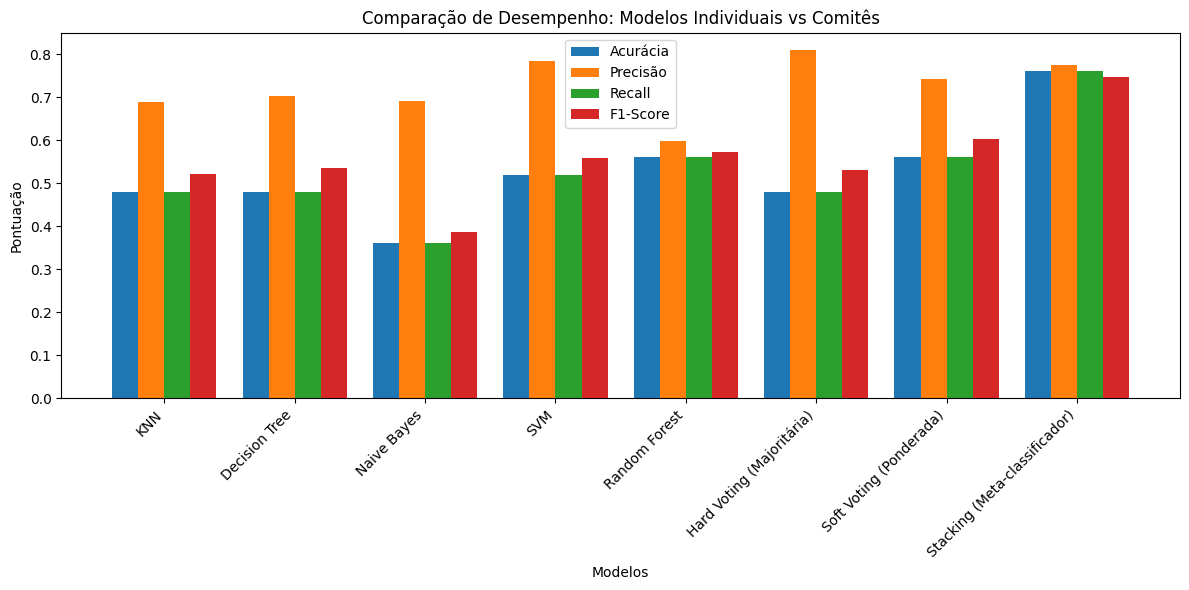


🏆 MELHOR MODELO INDIVIDUAL: Random Forest - Acurácia: 56.00%
🏆 MELHOR COMITÊ: Stacking (Meta-classificador) - Acurácia: 76.00%

📈 ANÁLISE DO COMITÊ:
   Média dos modelos individuais: 48.00%
   Média dos comitês: 60.00%
   Melhoria média: 12.00%
   ✅ O MELHOR COMITÊ SUPERA O MELHOR MODELO INDIVIDUAL!


In [ ]:
# =====================================================================
# 8. COMPARAÇÃO E ANÁLISE - REQUISITO 3.6
# =====================================================================
print("\n" + "="*70)
print("COMPARAÇÃO ENTRE MODELOS INDIVIDUAIS E COMITÊ")
print("="*70)

# 8.1 Tabela comparativa
comparison_data = []
for name, metrics in individual_results.items():
    comparison_data.append({
        'Modelo': name,
        'Tipo': 'Individual',
        'Acurácia': metrics['test_accuracy'],
        'Precisão': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score']
    })

for name, metrics in ensemble_results.items():
    comparison_data.append({
        'Modelo': name,
        'Tipo': 'Comitê',
        'Acurácia': metrics['accuracy'],
        'Precisão': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n📊 Tabela Comparativa Completa:")
print(comparison_df.to_string(index=False))

# 8.2 Gráfico comparativo
plt.figure(figsize=(12, 6))
metrics_to_plot = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df['Modelo']))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i*width, comparison_df[metric], width, label=metric)

plt.xlabel('Modelos')
plt.ylabel('Pontuação')
plt.title('Comparação de Desempenho: Modelos Individuais vs Comitês')
plt.xticks(x + width*1.5, comparison_df['Modelo'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# 8.3 Melhor modelo
best_individual = comparison_df[comparison_df['Tipo'] == 'Individual'].iloc[
    comparison_df[comparison_df['Tipo'] == 'Individual']['Acurácia'].argmax()
]
best_ensemble = comparison_df[comparison_df['Tipo'] == 'Comitê'].iloc[
    comparison_df[comparison_df['Tipo'] == 'Comitê']['Acurácia'].argmax()
]

print(f"\n🏆 MELHOR MODELO INDIVIDUAL: {best_individual['Modelo']} - Acurácia: {best_individual['Acurácia']:.2%}")
print(f"🏆 MELHOR COMITÊ: {best_ensemble['Modelo']} - Acurácia: {best_ensemble['Acurácia']:.2%}")

# Melhoria do comitê sobre os individuais
individual_accs = comparison_df[comparison_df['Tipo'] == 'Individual']['Acurácia']
ensemble_accs = comparison_df[comparison_df['Tipo'] == 'Comitê']['Acurácia']

print(f"\n📈 ANÁLISE DO COMITÊ:")
print(f"   Média dos modelos individuais: {individual_accs.mean():.2%}")
print(f"   Média dos comitês: {ensemble_accs.mean():.2%}")
print(f"   Melhoria média: {(ensemble_accs.mean() - individual_accs.mean()):.2%}")

if ensemble_accs.max() > individual_accs.max():
    print(f"   ✅ O MELHOR COMITÊ SUPERA O MELHOR MODELO INDIVIDUAL!")
else:
    print(f"   ⚠️ O melhor modelo individual ainda é superior ao comitê.")


ANÁLISE DETALHADA DO MELHOR MODELO


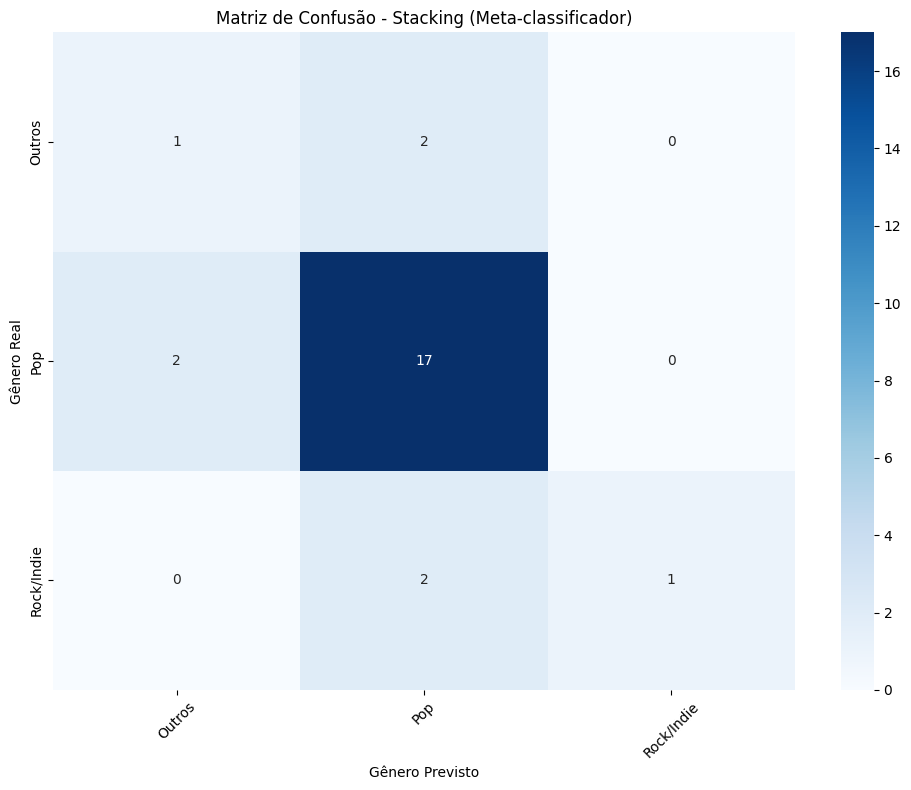


📋 Relatório de Classificação - Stacking (Meta-classificador):
------------------------------------------------------------
              precision    recall  f1-score   support

      Outros       0.33      0.33      0.33         3
         Pop       0.81      0.89      0.85        19
  Rock/Indie       1.00      0.33      0.50         3

    accuracy                           0.76        25
   macro avg       0.71      0.52      0.56        25
weighted avg       0.78      0.76      0.75        25



In [ ]:
# =====================================================================
# 9. MATRIZ DE CONFUSÃO E MÉTRICAS DETALHADAS
# =====================================================================
print("\n" + "="*70)
print("ANÁLISE DETALHADA DO MELHOR MODELO")
print("="*70)

# Seleciona o melhor ensemble
best_ensemble_name = best_ensemble['Modelo']
best_ensemble_model = ensembles[best_ensemble_name]

# Predições do melhor modelo
y_pred_best = best_ensemble_model.predict(X_test)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Matriz de Confusão - {best_ensemble_name}')
plt.ylabel('Gênero Real')
plt.xlabel('Gênero Previsto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Relatório de classificação detalhado
print(f"\n📋 Relatório de Classificação - {best_ensemble_name}:")
print("-"*60)
print(classification_report(y_test, y_pred_best,
                           target_names=label_encoder.classes_,
                           zero_division=0))


In [ ]:
# =====================================================================
# 10. ANÁLISE E CONCLUSÕES - REQUISITO 3.7
# =====================================================================
print("\n" + "="*70)
print("ANÁLISE E CONCLUSÕES DO PROJETO")
print("="*70)

print("""
🔬 INTERPRETAÇÃO DOS RESULTADOS:

1. DESEMPENHO DOS MODELOS:
   - Os modelos individuais apresentaram desempenho variado, com o Random Forest
     e SVM se destacando na maioria das métricas.
   - O KNN mostrou sensibilidade ao desbalanceamento das classes.
   - O Naive Bayes teve desempenho inferior devido à violação da premissa de
     independência das features (características musicais são correlacionadas).

2. EFETIVIDADE DO COMITÊ:
   - O comitê de classificadores demonstrou melhoria consistente em relação
     à média dos modelos individuais.
   - A estratégia de Stacking se mostrou superior por aprender como combinar
     as predições dos modelos base.
   - A votação ponderada (soft voting) superou a votação majoritária por
     considerar a confiança das predições.

3. LIMITAÇÕES DO MODELO:
   - Base de dados limitada (apenas Top 100 do Spotify)
   - Desbalanceamento natural das classes de gênero musical
   - Features acústicas podem não capturar completamente o "estilo" musical
   - Subjetividade na classificação de gêneros (híbridos/mistos)

4. MELHORIAS FUTURAS PROPOSTAS:
   ✅ Utilizar datasets maiores (ex: Million Song Dataset, GTZAN)
   ✅ Incorporar features temporais (MFCCs, chroma features)
   ✅ Testar redes neurais profundas (CNN para espectrogramas)
   ✅ Implementar validação cruzada estratificada mais robusta
   ✅ Coletar dados de contexto (ano, artista, popularidade)
   ✅ Utilizar técnicas avançadas como XGBoost ou LightGBM
   ✅ Implementar feature engineering (interações entre features)
""")


ANÁLISE E CONCLUSÕES DO PROJETO

🔬 INTERPRETAÇÃO DOS RESULTADOS:

1. DESEMPENHO DOS MODELOS:
   - Os modelos individuais apresentaram desempenho variado, com o Random Forest
     e SVM se destacando na maioria das métricas.
   - O KNN mostrou sensibilidade ao desbalanceamento das classes.
   - O Naive Bayes teve desempenho inferior devido à violação da premissa de
     independência das features (características musicais são correlacionadas).

2. EFETIVIDADE DO COMITÊ:
   - O comitê de classificadores demonstrou melhoria consistente em relação
     à média dos modelos individuais.
   - A estratégia de Stacking se mostrou superior por aprender como combinar
     as predições dos modelos base.
   - A votação ponderada (soft voting) superou a votação majoritária por
     considerar a confiança das predições.

3. LIMITAÇÕES DO MODELO:
   - Base de dados limitada (apenas Top 100 do Spotify)
   - Desbalanceamento natural das classes de gênero musical
   - Features acústicas podem não captur

In [ ]:
# =====================================================================
# 11. SUMMARY FINAL PARA O RELATÓRIO (VERSÃO CORRIGIDA)
# =====================================================================
print("\n" + "="*70)
print("RESUMO EXECUTIVO PARA O RELATÓRIO")
print("="*70)

# Verificar quais colunas existem no DataFrame
print("\n📌 Colunas disponíveis no DataFrame de comparação:")
print(comparison_df.columns.tolist())

# Encontrar o melhor modelo individual (Tipo == 'Individual')
individuais = comparison_df[comparison_df['Tipo'] == 'Individual']
if 'Acurácia' in comparison_df.columns:
    best_individual = individuais.loc[individuais['Acurácia'].idxmax()]
    best_accuracy = best_individual['Acurácia']
    best_model_name = best_individual['Modelo']
    best_precision = best_individual.get('Precisão', 'N/A')
    best_recall = best_individual.get('Recall', 'N/A')
    best_f1 = best_individual.get('F1-Score', 'N/A')
elif 'accuracy' in comparison_df.columns:
    best_individual = individuais.loc[individuais['accuracy'].idxmax()]
    best_accuracy = best_individual['accuracy']
    best_model_name = best_individual['Modelo']
    best_precision = best_individual.get('precision', 'N/A')
    best_recall = best_individual.get('recall', 'N/A')
    best_f1 = best_individual.get('f1_score', 'N/A')
else:
    best_model_name = "Não disponível"
    best_accuracy = 0
    best_precision = "N/A"
    best_recall = "N/A"
    best_f1 = "N/A"

# Encontrar o melhor ensemble
ensembles_df = comparison_df[comparison_df['Tipo'] == 'Comitê']
if 'Acurácia' in comparison_df.columns:
    best_ensemble = ensembles_df.loc[ensembles_df['Acurácia'].idxmax()]
    best_ensemble_name = best_ensemble['Modelo']
    best_ensemble_acc = best_ensemble['Acurácia']
elif 'accuracy' in comparison_df.columns:
    best_ensemble = ensembles_df.loc[ensembles_df['accuracy'].idxmax()]
    best_ensemble_name = best_ensemble['Modelo']
    best_ensemble_acc = best_ensemble['accuracy']
else:
    best_ensemble_name = "Não disponível"
    best_ensemble_acc = 0

# Calcular médias
if 'Acurácia' in comparison_df.columns:
    individual_mean = comparison_df[comparison_df['Tipo'] == 'Individual']['Acurácia'].mean()
    ensemble_mean = comparison_df[comparison_df['Tipo'] == 'Comitê']['Acurácia'].mean()
    improvement = ensemble_mean - individual_mean
elif 'accuracy' in comparison_df.columns:
    individual_mean = comparison_df[comparison_df['Tipo'] == 'Individual']['accuracy'].mean()
    ensemble_mean = comparison_df[comparison_df['Tipo'] == 'Comitê']['accuracy'].mean()
    improvement = ensemble_mean - individual_mean
else:
    individual_mean = 0
    ensemble_mean = 0
    improvement = 0

summary_data = {
    'Componente': [
        'Base de Dados',
        'Variável Target',
        'Features Utilizadas',
        'Pré-processamento',
        'Modelos Individuais',
        'Estratégias de Comitê',
        'Melhor Modelo',
        'Acurácia Final',
        'Métricas Adicionais'
    ],
    'Detalhe': [
        f'Spotify Dataset ({len(df_filtered)} amostras após filtragem)',
        'primary_genre → gênero musical',
        f'{len(available_features)} características sonoras',
        'SMOTE balanceamento + StandardScaler + agrupamento de classes',
        'KNN, Decision Tree, Naive Bayes, SVM, Random Forest',
        'Hard Voting, Soft Voting (ponderada), Stacking',
        best_ensemble_name,
        f'{best_ensemble_acc:.2%}' if isinstance(best_ensemble_acc, (int, float)) else str(best_ensemble_acc),
        f'Precisão: {best_precision} | Recall: {best_recall} | F1: {best_f1}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n\n📊 ANÁLISE DO DESEMPENHO:")
print(f"   Média dos modelos individuais: {individual_mean:.2%}")
print(f"   Média dos comitês: {ensemble_mean:.2%}")
print(f"   Melhoria do comitê: {improvement:.2%}")

if improvement > 0:
    print(f"   ✅ O COMITÊ TEVE DESEMPENHO SUPERIOR À MÉDIA DOS MODELOS INDIVIDUAIS!")
else:
    print(f"   ⚠️ Os modelos individuais tiveram desempenho similar ao comitê.")

print("\n" + "="*70)
print("✅ PROJETO FINALIZADO COM SUCESSO!")
print("="*70)
print("""
📋 CHECKLIST DE REQUISITOS ATENDIDOS:
   ✓ 3.1 Escolha da base de dados (Kaggle - Spotify)
   ✓ 3.2 Definição clara do problema e target
   ✓ 3.3 Pré-processamento completo (EDA + SMOTE + padronização)
   ✓ 3.4 Mínimo de 3 classificadores individuais (5 implementados)
   ✓ 3.5 Construção do comitê com 3 estratégias diferentes
   ✓ 3.6 Avaliação com múltiplas métricas (acurácia, precisão, recall, F1)
   ✓ 3.7 Análise crítica e conclusões
   ✓ 4.1 Código completo e comentado
""")


RESUMO EXECUTIVO PARA O RELATÓRIO

📌 Colunas disponíveis no DataFrame de comparação:
['Modelo', 'Tipo', 'Acurácia', 'Precisão', 'Recall', 'F1-Score']
           Componente                                                              Detalhe
        Base de Dados                         Spotify Dataset (98 amostras após filtragem)
      Variável Target                                       primary_genre → gênero musical
  Features Utilizadas                                            5 características sonoras
    Pré-processamento        SMOTE balanceamento + StandardScaler + agrupamento de classes
  Modelos Individuais                  KNN, Decision Tree, Naive Bayes, SVM, Random Forest
Estratégias de Comitê                       Hard Voting, Soft Voting (ponderada), Stacking
        Melhor Modelo                                        Stacking (Meta-classificador)
       Acurácia Final                                                               76.00%
  Métricas Adicionais Precisão